In [1]:
!pip install -q requests pandas numpy matplotlib scipy geopandas pycountry statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 42.4 MB/s eta 0:00:00


In [2]:
# ════════════════════════════════════════════════════════════════════════════════
# 0.  IMPORTS
# ════════════════════════════════════════════════════════════════════════════════
import os, time, warnings
import requests                          # HTTP calls to the OpenAlex API
import numpy  as np
import pandas as pd
import matplotlib.pyplot   as plt
import matplotlib.patches  as mpatches
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
from matplotlib.cm     import ScalarMappable  # used for choropleth colorbar

from scipy.stats import ttest_1samp     # one-sample t-test: is mean deficit ≠ 0?

import pycountry                         # ISO country code lookups
warnings.filterwarnings("ignore")

# ════════════════════════════════════════════════════════════════════════════════
# 1.  CONFIG
# ════════════════════════════════════════════════════════════════════════════════

API_KEY = "ENTER_API_KEY"   # OpenAlex polite-pool API key

# ── Sampling parameters ───────────────────────────────────────────────────────
# Sample size justification (a priori, before data collection):
#
# Our test is a one-sample t-test: is mean(last_deficit) significantly ≠ 0?
# The standard sample size formula for this test is:
#
#   n = ((z_α/2 + z_β) × SD / effect)²
#
# where:
#   z_α/2 = 1.96  (two-sided α = 0.05)
#   z_β   = 0.84  (80% power)
#   SD    ≈ 45%   (estimated SD of last_deficit — the difference between
#                  a binary 0/1 outcome and a proportion, bounded in [−1, 1])
#   effect        = the smallest deficit we want to be able to detect
#
# Plugging in a conservative minimum detectable effect of 5%:
#   n = ((1.96 + 0.84) × 45 / 5)² = (2.80 × 9)² ≈ 636 papers
#
# We set TARGET_PER_FIELD = 750 to give a modest buffer above this threshold.
# The SD assumption of 45% was verified against the actual data after collection.
TARGET_PER_FIELD = 750   # papers to collect per academic field
TOP_N_FIELDS     = 20    # maximum number of fields to include

# Papers with fewer than 2 or more than 15 authors are excluded:
#   <2 authors: no meaningful first/last distinction
#   >15 authors: large consortia where authorship order is often non-hierarchical
AUTHOR_MIN = 2
AUTHOR_MAX = 15

# Study window: covers the rise of international open-science rhetoric
YEAR_START = 2005
YEAR_END   = 2023

# ── API request settings ──────────────────────────────────────────────────────
REQUEST_DELAY    = 0.13  # seconds between requests — stays within OpenAlex rate limits
PAGE_SIZE        = 200   # results per API page (OpenAlex maximum)

# Drop any field from the analysis if fewer than this many mixed papers were
# found — prevents unstable estimates from near-empty strata
MIN_FIELD_PAPERS = 200

# If True, ignore cached CSVs and re-collect everything from the API.
# Set to False during analysis to avoid re-running the ~15-minute collection.
FORCE_REFRESH = False

# ── File paths ────────────────────────────────────────────────────────────────
DATA_DIR    = "data"
FIGURES_DIR = "figures"
PAPERS_CSV  = "data/papers.csv"    # one row per paper
AUTHORS_CSV = "data/authors.csv"   # one row per author-country-paper combination
BASE        = "https://api.openalex.org"

os.makedirs(DATA_DIR,    exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

# ── Colours ───────────────────────────────────────────────────────────────────
# Red = Global South (GS), Dark Blue = Global North (GN).
# Used consistently across all figures so colour carries meaning throughout.
GS_COL = "#E63946"   # red  — Global South
GN_COL = "#1a4f7a"   # blue — Global North
BG     = "#F8F9FA"   # off-white background, easier on the eye than pure white
SERIF  = "DejaVu Serif"   # serif font for all figure text — matches poster style

# ── Global matplotlib defaults ────────────────────────────────────────────────
# Set once here so every figure inherits the same style without repeating code
plt.rcParams.update({
    "font.family":        "DejaVu Sans",
    "font.size":          10,
    "axes.titlesize":     11,
    "axes.titleweight":   "bold",
    "axes.spines.top":    False,   # remove top and right chart borders
    "axes.spines.right":  False,   # for a cleaner, modern look
    "axes.facecolor":     BG,
    "figure.facecolor":   BG,
    "figure.dpi":         130,     # screen preview resolution
    "savefig.dpi":        200,     # saved file resolution (high enough for poster)
    "savefig.bbox":       "tight",
    "savefig.facecolor":  BG,
    "grid.alpha":         0.25,    # subtle grid — present but not distracting
    "grid.linestyle":     "--",
    "axes.grid":          True,
})


def _save(name):
    """Save the current figure to FIGURES_DIR and display it inline."""
    path = f"{FIGURES_DIR}/{name}.png"
    plt.savefig(path, bbox_inches="tight", facecolor=BG)
    plt.show()
    print(f"  ✓ saved {path}")


def _sig(p_value):
    """
    Convert a p-value to a significance star string.
    Standard scientific convention:
      ***  p < 0.001
      **   p < 0.01
      *    p < 0.05
      ns   not significant
    """
    try:
        p_value = float(p_value)
        if p_value < 0.001: return "***"
        if p_value < 0.01:  return "**"
        if p_value < 0.05:  return "*"
        return "ns"
    except Exception:
        return "ns"


# ── Field display name overrides ──────────────────────────────────────────────
# Some OpenAlex field names are too long to fit cleanly on figure axes.
# This dict maps the full API name to a shorter display version.
# Applied in figures with: fdf["field"] = fdf["field"].replace(FIELD_SHORT)
FIELD_SHORT = {
    "Pharmacology, Toxicology and Pharmaceutics":   "Pharmacology",
    "Agricultural and Biological Sciences":          "Agricultural & Bio",
    "Biochemistry, Genetics and Molecular Biology":  "Biochemistry & Genetics",
}

In [3]:
# ════════════════════════════════════════════════════════════════════════════════
# 2.  COUNTRY CLASSIFICATION
# ════════════════════════════════════════════════════════════════════════════════

# World Bank API endpoint — returns all countries with income classifications
WORLD_BANK_COUNTRIES_URL = (
    "https://api.worldbank.org/v2/country?format=json&per_page=400"
)

# Path to cache the classification so we don't hit the World Bank API
# on every run. Delete this file to force a fresh fetch.
WB_CACHE_PATH = "data/worldbank_countries.csv"


def fetch_global_south_countries():
    """
    Fetch country classifications from the World Bank API and return
    all non-high-income countries as the Global South set.

    Classification rule: a country is Global South if its World Bank
    income group is NOT "High income" (income_id != "HIC").

    This is a standard, citable definition used in development economics.
    It includes China (upper-middle income), India (lower-middle income),
    Brazil (upper-middle income), and all of Africa and South Asia.

    Returns a DataFrame with one row per country and their classifications.
    """
    print("  Fetching country classifications from World Bank API...")
    response = requests.get(WORLD_BANK_COUNTRIES_URL, timeout=30)
    response.raise_for_status()

    # World Bank returns [metadata, data] — we want index 1
    _, raw_countries = response.json()

    rows = []
    for country in raw_countries:
        iso2      = country.get("iso2Code", "").strip()
        income_id = (country.get("incomeLevel") or {}).get("id", "")
        region    = (country.get("region")      or {}).get("value", "")

        # Skip aggregates (e.g. "World", "Sub-Saharan Africa") and
        # invalid entries — these are not individual countries
        if not iso2 or iso2 in {"", "NA", "XX"}:
            continue
        if region == "Aggregates":
            continue

        # High income (HIC) = Global North — exclude from GS set
        # All other income groups (LIC, LMC, UMC) = Global South
        if income_id == "HIC":
            continue

        rows.append({
            "iso2":       iso2,
            "name":       country.get("name"),
            "region":     region,
            "income":     (country.get("incomeLevel") or {}).get("value"),
            "income_id":  income_id,
            "lending":    (country.get("lendingType") or {}).get("value"),
            "lending_id": (country.get("lendingType") or {}).get("id"),
        })

    return pd.DataFrame(rows)


def load_global_south():
    """
    Load the Global South country set, using a cached CSV if available.
    Fetches fresh from the World Bank API if the cache does not exist.

    Caching avoids a network call on every notebook run while keeping
    the classification transparent and reproducible.
    """
    if os.path.exists(WB_CACHE_PATH):
        gs_df = pd.read_csv(WB_CACHE_PATH)
        print(f"  Loaded {len(gs_df)} GS countries from cache "
              f"({WB_CACHE_PATH})")
    else:
        gs_df = fetch_global_south_countries()
        os.makedirs(DATA_DIR, exist_ok=True)
        gs_df.to_csv(WB_CACHE_PATH, index=False)
        print(f"  Fetched and cached {len(gs_df)} GS countries "
              f"→ {WB_CACHE_PATH}")
    return gs_df


def _build_iso2_map():
    """
    Build a lookup dictionary from ISO-2 country codes to full country names.
    Uses pycountry as base, then overrides awkward official names with
    common names for readability in figures (e.g. choropleth labels).
    """
    iso2_to_name = {}
    for country in pycountry.countries:
        try:
            iso2_to_name[country.alpha_2] = country.name
        except:
            pass
    # Override with cleaner common names for readability in figures
    iso2_to_name.update({
        "US":"United States","GB":"United Kingdom","KR":"South Korea",
        "IR":"Iran","TW":"Taiwan","RU":"Russia","VN":"Vietnam",
        "TZ":"Tanzania","BO":"Bolivia","MD":"Moldova","CN":"China",
        "IN":"India","BR":"Brazil","TR":"Turkey","MX":"Mexico",
    })
    return iso2_to_name

# Pre-built at import time so lookups are O(1) throughout the notebook
ISO2_TO_COUNTRY_NAME = _build_iso2_map()


def iso2name(iso2_code):
    """Convert an ISO-2 country code (e.g. 'CN') to a readable name ('China').
    Falls back to the raw code if not found."""
    return ISO2_TO_COUNTRY_NAME.get(
        str(iso2_code).strip().upper(),
        str(iso2_code).strip()
    )


def author_is_gs(auth):
    """
    Classify a single author as Global South (True), Global North (False),
    or unknown (None if no country data available in OpenAlex).

    An author is GS if ANY of their affiliated institutions is in GLOBAL_SOUTH.
    GLOBAL_SOUTH is derived from the World Bank API — all non-high-income
    countries (LIC, LMC, UMC).

    Dual-affiliated authors (e.g. India + USA) are classified as GS — this is
    conservative and slightly inflates the GS author count, but is the correct
    methodological choice since the author has a genuine GS affiliation.
    """
    country_codes = [str(c) for c in (auth.get("countries") or []) if c]
    if not country_codes:
        return None   # affiliation unknown — excluded from deficit calculations
    return any(code in GLOBAL_SOUTH for code in country_codes)


def get_country_list(auth):
    """Return list of ISO-2 country codes for a single author's affiliations."""
    return [str(c) for c in (auth.get("countries") or []) if c]


# ── Build the Global South set ────────────────────────────────────────────────
# Classification: all World Bank non-high-income countries (LIC, LMC, UMC).
# Source: World Bank API — transparent, citable, and automatically updated
# if a country's income classification changes between study runs.
# All downstream functions (author_is_gs, fig3_choropleth, etc.) use this set.
_gs_df       = load_global_south()
GLOBAL_SOUTH = set(_gs_df["iso2"].dropna().str.strip().str.upper())

# ── Sanity checks — verify the classification is correct ──────────────────────
print(f"\n  Global South: {len(GLOBAL_SOUTH)} countries")
print(f"  Income groups: {_gs_df['income'].value_counts().to_dict()}")
print(f"\n  Inclusion checks (should all be True):")
print(f"    China  (CN, upper-middle income): {'CN' in GLOBAL_SOUTH}")
print(f"    India  (IN, lower-middle income): {'IN' in GLOBAL_SOUTH}")
print(f"    Brazil (BR, upper-middle income): {'BR' in GLOBAL_SOUTH}")
print(f"\n  Exclusion checks (should all be False):")
print(f"    USA    (US, high income): {'US' in GLOBAL_SOUTH}")
print(f"    Germany (DE, high income): {'DE' in GLOBAL_SOUTH}")
print(f"    Japan  (JP, high income): {'JP' in GLOBAL_SOUTH}")


# ════════════════════════════════════════════════════════════════════════════════
# 3.  API HELPER
# ════════════════════════════════════════════════════════════════════════════════

def api_get(endpoint, params, retries=5):
    """
    Make a GET request to the OpenAlex API with automatic retry logic.

    Handles two common failure modes:
      - HTTP 429 (rate limited): waits an increasing amount of time before retrying
      - Network errors: retries with exponential backoff

    Parameters
    ----------
    endpoint : str
        API endpoint to query, e.g. "works" or "fields"
    params : dict
        Query parameters (field filters, pagination cursor, etc.)
    retries : int
        Maximum number of attempts before giving up

    Returns
    -------
    dict
        Parsed JSON response from the API
    """
    # Add API key to every request for polite-pool access (higher rate limits)
    request_params = dict(params)
    request_params["api_key"] = API_KEY

    for attempt in range(retries):
        time.sleep(REQUEST_DELAY)   # always pause between requests
        try:
            response = requests.get(
                f"{BASE}/{endpoint}",
                params=request_params,
                timeout=30
            )

            if response.status_code == 429:
                # Rate limited — wait longer on each successive attempt
                wait_seconds = 60 * (attempt + 1)
                print(f"  ⚠ rate limited — waiting {wait_seconds}s...")
                time.sleep(wait_seconds)
                continue

            response.raise_for_status()   # raise on 4xx/5xx errors
            return response.json()

        except requests.RequestException as e:
            print(f"  ⚠ attempt {attempt+1}/{retries}: {e}")
            time.sleep(15 * (attempt + 1))   # exponential backoff

    raise RuntimeError("OpenAlex API failed after retries")

  Fetching country classifications from World Bank API...
  Fetched and cached 130 GS countries → data/worldbank_countries.csv

  Global South: 130 countries
  Income groups: {'Upper middle income': 54, 'Lower middle income': 49, 'Low income': 25, 'Not classified': 2}

  Inclusion checks (should all be True):
    China  (CN, upper-middle income): True
    India  (IN, lower-middle income): True
    Brazil (BR, upper-middle income): True

  Exclusion checks (should all be False):
    USA    (US, high income): False
    Germany (DE, high income): False
    Japan  (JP, high income): False


In [4]:
# ════════════════════════════════════════════════════════════════════════════════
# 4.  DATA COLLECTION
# ════════════════════════════════════════════════════════════════════════════════

# These OpenAlex field IDs are excluded because alphabetical authorship
# conventions in these disciplines make last-author PI attribution unreliable.
# Mathematics=26, Computer Science=17, Economics=20, Business=14,
# Social Sciences=33, Arts and Humanities=12, Decision Sciences=18
EXCLUDED_FIELD_IDS = {"26", "17", "20", "14", "33", "12", "18"}


def fetch_top_fields(n=TOP_N_FIELDS):
    """
    Query OpenAlex to find the top N fields by paper count within our
    study population (mixed GS+GN international collaborations).

    Importantly, we rank fields by their count WITHIN the filtered population
    (mixed GS+GN papers), not by global paper volume. This ensures we select
    fields where international GS+GN collaboration is actually common.

    Returns a list of dicts with field_id, field_name, and available count.
    """
    print("\nFetching top fields from OpenAlex...")
    data = api_get("works", {
        # Filter to our study population before ranking fields
        "filter": (
            f"authorships.institutions.is_global_south:true,"
            f"type:article,"
            f"publication_year:{YEAR_START}-{YEAR_END},"
            f"authors_count:{AUTHOR_MIN}-{AUTHOR_MAX},"
            f"countries_distinct_count:2-100"
        ),
        "group_by": "primary_topic.field.id",  # count papers per field
        "per-page": 50,  # fetch more than needed so we have enough after exclusions
    })

    fields = []
    for field_group in (data.get("group_by") or []):
        # OpenAlex returns field IDs as full URLs — extract just the numeric ID
        raw_id = str(field_group.get("key", "")).rstrip("/").split("/")[-1]

        if raw_id in EXCLUDED_FIELD_IDS:
            continue  # skip fields where last-author convention doesn't apply

        fields.append({
            "field_id":   raw_id,
            "field_name": field_group.get("key_display_name", "Unknown"),
            "count":      int(field_group.get("count", 0)),
        })

        if len(fields) >= n:
            break

    print(f"  Using {len(fields)} senior-authorship-norm fields:")
    for f in fields:
        print(f"    {f['field_name']:48s}  id={f['field_id']:>4s}  "
              f"{f['count']:>12,} papers")
    return fields


def _paper_is_mixed(authorships):
    """
    Returns True only if a paper has at least one confirmed GS author
    AND at least one confirmed GN author with known institutional country.

    This is the core inclusion criterion — we only study papers where
    both groups are present, so that authorship position competition
    between GS and GN authors is directly observable.
    """
    # Only consider authors whose country affiliation is known
    authors_with_known_country = [a for a in (authorships or []) if a.get("countries")]
    gs_flags = [author_is_gs(a) for a in authors_with_known_country]
    has_gs   = any(flag is True  for flag in gs_flags)
    has_gn   = any(flag is False for flag in gs_flags)
    return has_gs and has_gn


def collect_papers(fields):
    """
    Collect TARGET_PER_FIELD mixed GS+GN papers for each field using
    OpenAlex cursor-based pagination.

    Strategy:
    - For each field, page through results until we have enough mixed papers
    - The API filter pre-selects papers with at least one GS institution,
      but we still need to post-filter for genuinely mixed (GS+GN) papers
    - Papers are tagged with their field name for downstream use
    - Fields with fewer than MIN_FIELD_PAPERS available are dropped entirely
      to avoid unstable estimates from very sparse strata
    """
    all_papers = []
    print(f"\n{'='*62}")
    print(f"STRATIFIED COLLECTION")
    print(f"Target: {TARGET_PER_FIELD} mixed papers × {len(fields)} fields = "
          f"{TARGET_PER_FIELD * len(fields):,}")
    print(f"Authors/paper: {AUTHOR_MIN}–{AUTHOR_MAX} | Years: {YEAR_START}–{YEAR_END}")
    print(f"{'='*62}")

    for field in fields:
        field_id   = field["field_id"]
        field_name = field["field_name"]
        field_papers = []
        cursor     = "*"   # OpenAlex uses cursor-based pagination; "*" = first page
        print(f"\n  [{field_name}]  target={TARGET_PER_FIELD}...")

        while len(field_papers) < TARGET_PER_FIELD:
            try:
                data = api_get("works", {
                    "filter": (
                        f"primary_topic.field.id:{field_id},"
                        f"authorships.institutions.is_global_south:true,"
                        f"type:article,"
                        f"publication_year:{YEAR_START}-{YEAR_END},"
                        f"authors_count:{AUTHOR_MIN}-{AUTHOR_MAX},"
                        f"countries_distinct_count:2-100"
                    ),
                    # Minimal select — only request fields we actually use.
                    # Requesting fewer fields reduces response size and speeds up collection.
                    "select": (
                        "id,authorships,publication_year,primary_topic,"
                        "cited_by_count,fwci,countries_distinct_count"
                    ),
                    "per-page": PAGE_SIZE,
                    "cursor":   cursor,
                })
            except RuntimeError as e:
                print(f"    ⚠ API failure, skipping field: {e}")
                break

            page_results = data.get("results") or []
            if not page_results:
                break  # no more results available for this field

            for work in page_results:
                authorships = work.get("authorships") or []
                # Post-filter: the API guarantees at least one GS institution,
                # but we need to confirm the paper is genuinely mixed (GS + GN)
                if _paper_is_mixed(authorships):
                    field_papers.append(work)
                    if len(field_papers) >= TARGET_PER_FIELD:
                        break

            # Get the cursor for the next page; None means we've exhausted results
            cursor = (data.get("meta") or {}).get("next_cursor")
            if not cursor:
                break

        n_collected = len(field_papers)
        if n_collected < MIN_FIELD_PAPERS:
            # Too few papers — estimates would be unreliable, drop the field
            print(f"    ⚠ only {n_collected} papers — dropping field")
            continue

        # Trim to exactly TARGET_PER_FIELD for equal stratification
        field_papers = field_papers[:TARGET_PER_FIELD]

        # Tag each paper with its field name so flatten_papers can use it
        for paper in field_papers:
            paper["_field_name"] = field_name

        all_papers.extend(field_papers)
        print(f"    collected {n_collected}  |  total: {len(all_papers)}")

    print(f"\n✓ Collected {len(all_papers)} papers across "
          f"{len(set(p['_field_name'] for p in all_papers))} fields")
    return all_papers


# ════════════════════════════════════════════════════════════════════════════════
# 5.  FLATTENING
# ════════════════════════════════════════════════════════════════════════════════

def _safe_fwci(work):
    """
    Safely extract FWCI (Field-Weighted Citation Impact) from a work dict.
    FWCI > 1 means the paper is cited more than the field average.
    Returns np.nan if missing — common for recent papers or smaller journals.
    """
    raw_value = work.get("fwci")
    try:
        return float(raw_value)
    except:
        return np.nan


def flatten_papers(works):
    """
    Convert raw API work dicts into a clean DataFrame with one row per paper.

    Key computed columns:
      gs_frac       — fraction of known-affiliation authors who are GS
                      This is the "expected" GS rate under random assignment
      first_is_gs   — True/False/None: is the first author GS?
      last_is_gs    — True/False/None: is the last author GS?
      first_deficit — first_is_gs − gs_frac: positive = GS over-represented
      last_deficit  — last_is_gs  − gs_frac: negative = GS under-represented

    The deficit is our core estimand. It answers: "Given how many GS authors
    are on this paper, does a GS researcher hold this position more or less
    often than random assignment would predict?"
    """
    rows = []
    for work in (works or []):
        try:
            authorships = work.get("authorships") or []
            year        = int(work.get("publication_year") or 0)

            # Use the tagged field name from collection; fall back to API field
            field = work.get("_field_name") or (
                ((work.get("primary_topic") or {}).get("field") or {})
                .get("display_name", "Unknown"))

            citation_count = int(work.get("cited_by_count") or 0)
            fwci           = _safe_fwci(work)
            n_countries    = int(work.get("countries_distinct_count") or 0)
            paper_id       = str(work.get("id", ""))

            # ── Team composition ──────────────────────────────────────────────
            # Only count authors whose country affiliation is known in OpenAlex
            authors_known_country = [a for a in authorships if a.get("countries")]
            gs_authors = [a for a in authors_known_country if author_is_gs(a) is True]
            gn_authors = [a for a in authors_known_country if author_is_gs(a) is False]
            n_gs = len(gs_authors)
            n_gn = len(gn_authors)
            n_authors_known = n_gs + n_gn

            if n_authors_known == 0:
                continue  # cannot compute deficit without any affiliation data

            # gs_frac = the "expected" GS authorship rate under random assignment
            # If a paper has 3 GS and 1 GN author, gs_frac = 0.75,
            # meaning GS should hold 75% of positions by chance alone
            gs_frac = n_gs / n_authors_known

            # ── Positional classification ──────────────────────────────────────
            # First author = execution credit (runs the experiments)
            # Last author  = PI credit (leads the lab, holds the grant)
            first_author = next(
                (a for a in authorships if a.get("author_position") == "first"), None)
            last_author  = next(
                (a for a in authorships if a.get("author_position") == "last"),  None)

            def _get_gs_status(author):
                """Return GS status of an author, or None if affiliation unknown."""
                if author is None or not author.get("countries"):
                    return None
                return author_is_gs(author)

            first_is_gs = _get_gs_status(first_author)
            last_is_gs  = _get_gs_status(last_author)

            # ── Deficit calculation ────────────────────────────────────────────
            # deficit = observed (0 or 1) − expected (gs_frac)
            # Positive: GS holds this position more than their share predicts
            # Negative: GS holds this position less than their share predicts
            # None: position affiliation unknown — excluded from t-tests
            first_deficit = (float(first_is_gs) - gs_frac) \
                            if first_is_gs is not None else np.nan
            last_deficit  = (float(last_is_gs)  - gs_frac) \
                            if last_is_gs  is not None else np.nan

            rows.append({
                "paper_id":       paper_id,
                "year":           year,
                "field":          field,
                "n_authors":      len(authorships),
                "n_gs":           n_gs,
                "n_gn":           n_gn,
                "gs_frac":        round(gs_frac, 4),
                "n_countries":    n_countries,
                "cited_by_count": citation_count,
                "fwci":           fwci,
                "first_is_gs":    first_is_gs,
                "last_is_gs":     last_is_gs,
                "first_deficit":  round(first_deficit, 4)
                                  if not pd.isna(first_deficit) else np.nan,
                "last_deficit":   round(last_deficit, 4)
                                  if not pd.isna(last_deficit)  else np.nan,
            })
        except Exception as e:
            print(f"  ⚠ skipping malformed work: {e}")
            continue

    # Drop duplicates that may arise if a paper matched multiple field queries
    df = pd.DataFrame(rows).drop_duplicates("paper_id").reset_index(drop=True)
    return df


def flatten_authors(works):
    """
    Convert raw API work dicts into an author-level DataFrame with one row
    per author-country-paper combination. Used only by fig3_choropleth.

    Each row records which country the author is affiliated with,
    their authorship position, and the paper's gs_frac — so we can
    compute per-country deficit averages for the map.
    """
    rows = []
    for work in (works or []):
        try:
            authorships = work.get("authorships") or []
            year        = int(work.get("publication_year") or 0)
            field       = work.get("_field_name") or (
                ((work.get("primary_topic") or {}).get("field") or {})
                .get("display_name", "Unknown"))
            paper_id = str(work.get("id", ""))

            # Compute gs_frac for this paper (needed for choropleth deficit calc)
            authors_known_country = [a for a in authorships if a.get("countries")]
            n_gs    = sum(1 for a in authors_known_country if author_is_gs(a) is True)
            n_gn    = sum(1 for a in authors_known_country if author_is_gs(a) is False)
            n_known = n_gs + n_gn
            gs_frac = n_gs / n_known if n_known > 0 else np.nan

            # One row per author per country — an author with two country
            # affiliations generates two rows (both get the same position/gs_frac)
            for author in authorships:
                if not author.get("countries"):
                    continue  # skip authors with no affiliation data

                is_gs = author_is_gs(author)
                if is_gs is None:
                    continue  # skip unknown classification

                position     = author.get("author_position")
                country_list = get_country_list(author)

                for country_code in country_list:
                    rows.append({
                        "paper_id":     paper_id,
                        "year":         year,
                        "field":        field,
                        "country":      iso2name(country_code),  # full name for display
                        "country_iso2": country_code,            # ISO code for map merging
                        "position":     position,
                        "is_gs":        is_gs,
                        "gs_frac":      gs_frac,
                    })
        except Exception:
            continue

    return pd.DataFrame(rows)


def add_citation_quartile(df_papers):
    """
    Assign each paper a citation quartile relative to other papers in the
    same field and year. This controls for the fact that older papers
    naturally accumulate more citations.

    Q1 = top 25% most-cited within field-year (highest impact)
    Q4 = bottom 25% least-cited within field-year (lowest impact)

    Used in Analysis 2 to test whether the last-authorship deficit is
    driven by GS researchers publishing in lower-impact venues.

    Falls back to field-level quartiles if a field-year cell has fewer
    than 8 papers (too small for stable quartile boundaries).
    """
    df_papers = df_papers.copy()
    df_papers["cite_q"] = np.nan

    def _qcut_safe(citation_counts):
        """Safely compute quartile labels, returning NaN if too few papers."""
        citation_counts = pd.to_numeric(citation_counts, errors="coerce").fillna(0)
        if citation_counts.nunique() < 4 or len(citation_counts) < 8:
            return pd.Series(np.nan, index=citation_counts.index)
        try:
            # rank(method="first") breaks ties by order of appearance
            return pd.qcut(
                citation_counts.rank(method="first"), 4,
                labels=["Q4", "Q3", "Q2", "Q1"],  # Q1=top, Q4=bottom
                duplicates="drop"
            ).astype(str)
        except Exception:
            return pd.Series(np.nan, index=citation_counts.index)

    # Primary: assign quartiles within each field-year cell
    for (field, year), group in df_papers.groupby(["field", "year"]):
        quartile_labels = _qcut_safe(group["cited_by_count"])
        df_papers.loc[group.index, "cite_q"] = quartile_labels.values

    # Fallback: for papers still missing quartile, use field-level quartiles
    for field, group in df_papers.groupby("field"):
        still_missing = group[group["cite_q"].isna()]
        if len(still_missing) == 0:
            continue
        quartile_labels = _qcut_safe(still_missing["cited_by_count"])
        df_papers.loc[still_missing.index, "cite_q"] = quartile_labels.values

    # Final fallback: assign Q2 (median) to any remaining missing values
    df_papers["cite_q"] = df_papers["cite_q"].fillna("Q2")
    return df_papers


def build_dataframes():
    """
    Master data loading function. Either loads from CSV cache (fast, ~5s)
    or collects fresh from the OpenAlex API (slow, ~15 min).

    Set FORCE_REFRESH = True in Config to ignore the cache and re-collect.

    Returns
    -------
    df_papers  : DataFrame, one row per paper
    df_authors : DataFrame, one row per author-country-paper
    """
    if not FORCE_REFRESH \
       and os.path.exists(PAPERS_CSV) \
       and os.path.exists(AUTHORS_CSV):
        # ── Load from cache ───────────────────────────────────────
        print(f"\nLoading cached data...")
        df_papers  = pd.read_csv(PAPERS_CSV)
        df_authors = pd.read_csv(AUTHORS_CSV)
        print(f"  {len(df_papers):,} papers  |  {len(df_authors):,} author rows")

    else:
        # ── Collect fresh from API ────────────────────────────────
        fields     = fetch_top_fields(TOP_N_FIELDS)
        works      = collect_papers(fields)

        print("\nFlattening...")
        df_papers  = flatten_papers(works)
        df_authors = flatten_authors(works)
        df_papers  = add_citation_quartile(df_papers)

        # A paper may have been collected for multiple fields if its topic
        # overlaps — keep only the first occurrence
        n_before  = len(df_papers)
        df_papers = df_papers.drop_duplicates("paper_id").reset_index(drop=True)
        n_dupes   = n_before - len(df_papers)
        if n_dupes > 0:
            print(f"  ⚠ Removed {n_dupes} cross-field duplicate papers")

        # Cache to CSV so future runs load instantly
        df_papers.to_csv(PAPERS_CSV,   index=False)
        df_authors.to_csv(AUTHORS_CSV, index=False)

    # ── Sanity checks ──────────────────────────────────────────────────────────
    # Run after every load (cache or fresh) to catch data integrity problems
    print(f"\n{'='*50}")
    print(f"SANITY CHECK")
    print(f"{'='*50}")

    print(f"\n  Papers:             {len(df_papers):,}")
    print(f"  Author rows:        {len(df_authors):,}")
    print(f"  Years:              "
          f"{df_papers['year'].min()}–{df_papers['year'].max()}")
    print(f"  Fields:             {df_papers['field'].nunique()}")

    # Per-field counts — all should be close to TARGET_PER_FIELD (750)
    print(f"\n  Per-field paper counts:")
    for field, count in df_papers["field"].value_counts().sort_index().items():
        print(f"    {str(field):45s}  {count:,}")

    # Flag years with very few papers — could indicate API gaps
    yr_counts = df_papers["year"].value_counts().sort_index()
    sparse    = yr_counts[yr_counts < 50]
    if len(sparse):
        print(f"\n  ⚠ Sparse years (< 50 papers): {sparse.to_dict()}")
    else:
        print(f"\n  Year coverage: all {len(yr_counts)} years ≥ 50 papers  ✓")

    # Deficit summary — mean should be negative (last) and positive (first)
    # as a basic check that the estimand is computing correctly
    last_deficits  = df_papers["last_deficit"].dropna()
    first_deficits = df_papers["first_deficit"].dropna()
    print(f"\n  Last-authorship deficit:   "
          f"mean={last_deficits.mean()*100:+.2f}%  "
          f"SD={last_deficits.std()*100:.2f}%  n={len(last_deficits):,}")
    print(f"  First-authorship surplus:  "
          f"mean={first_deficits.mean()*100:+.2f}%  "
          f"SD={first_deficits.std()*100:.2f}%  n={len(first_deficits):,}")

    # gs_frac should be between 0 and 1, mean around 0.4–0.6 for mixed papers
    gs_fracs = df_papers["gs_frac"].dropna()
    print(f"\n  gs_frac (team GS share):  mean={gs_fracs.mean():.3f}  "
          f"min={gs_fracs.min():.3f}  max={gs_fracs.max():.3f}")

    # Missing affiliation data means those papers are excluded from deficit tests
    n_miss_first = df_papers["first_is_gs"].isna().sum()
    n_miss_last  = df_papers["last_is_gs"].isna().sum()
    n_total      = len(df_papers)
    print(f"\n  Missing first author affiliation:  "
          f"{n_miss_first:,}  ({100*n_miss_first/n_total:.1f}%)")
    print(f"  Missing last author affiliation:   "
          f"{n_miss_last:,}  ({100*n_miss_last/n_total:.1f}%)")
    print(f"  Papers with computable last_deficit: "
          f"{df_papers['last_deficit'].notna().sum():,}  "
          f"({100*df_papers['last_deficit'].notna().mean():.1f}%)")

    print(f"\n{'='*50}")
    return df_papers, df_authors

In [5]:
# ════════════════════════════════════════════════════════════════════════════════
# 6.  ANALYSES
# ════════════════════════════════════════════════════════════════════════════════

def mcnemar_paper(df_papers, col_first="first_is_gs", col_last="last_is_gs"):
    """
    McNemar's test on paired paper-level data (continuity-corrected).

    Why McNemar and not a chi-square test?
    Within each paper, first and last authorship positions are not independent
    — they are mechanically constrained (one paper, fixed positions). A standard
    chi-square test would treat each authorship slot as an independent observation,
    which is wrong. McNemar's test operates at the paper level, asking:
    "Among papers where GS and GN hold different positions, do GS authors
    disproportionately end up first rather than last?"

    The 2×2 contingency table is:
                        Last = GS    Last = GN
      First = GS           a            b       ← GS first AND last / GS first only
      First = GN           c            d       ← GN first, GS last / GN both

    McNemar only uses the discordant cells b and c:
      b = papers where GS is first but NOT last (GS does execution, GN gets PI credit)
      c = papers where GS is last but NOT first (GS gets PI credit — the rare case)

    If b >> c, GS systematically ends up in execution roles rather than PI roles.

    Continuity correction: (|b - c| - 1)² / (b + c)
    Applied to prevent inflated chi-square when b and c are small.
    """
    from scipy.stats import chi2 as chi2_dist

    # Only use papers where BOTH first and last author affiliation are known
    paired_papers = df_papers.dropna(subset=[col_first, col_last]).copy()

    if len(paired_papers) == 0:
        return dict(first_gs_rate=0., last_gs_rate=0., gap=0.,
                    n_paired=0, b=0, c=0, p_mcnemar=1.)

    first_is_gs = paired_papers[col_first].astype(float).astype(bool)
    last_is_gs  = paired_papers[col_last].astype(float).astype(bool)

    # Discordant cell b: GS first, GN last — execution role for GS
    b = int(( first_is_gs & ~last_is_gs).sum())
    # Discordant cell c: GN first, GS last — PI credit for GS (the rare case)
    c = int((~first_is_gs &  last_is_gs).sum())

    if (b + c) == 0:
        p_val = 1.   # no discordant pairs — cannot test
    else:
        # Continuity-corrected McNemar statistic
        chi2_stat = (max(abs(b - c) - 1, 0) ** 2) / (b + c)
        p_val     = float(1. - chi2_dist.cdf(chi2_stat, df=1))

    return dict(
        first_gs_rate = first_is_gs.mean() * 100,   # % of papers where GS is first
        last_gs_rate  = last_is_gs.mean()  * 100,   # % of papers where GS is last
        gap           = (first_is_gs.mean() - last_is_gs.mean()) * 100,  # first − last
        n_paired = len(paired_papers),
        b = b,   # GS first, GN last
        c = c,   # GN first, GS last
        p_mcnemar = p_val,
    )


def analysis_headline(df_papers):
    """
    Analysis 1: Primary test of the PI-credit gap.

    Two complementary approaches:

    (A) McNemar test — asks: within papers where GS and GN hold
        different positions, do GS authors disproportionately end up
        first (execution) rather than last (PI credit)?
        Unit of analysis: the paper. Avoids pseudo-replication.

    (B) One-sample t-test on deficit — asks: is the mean last-authorship
        deficit (observed GS last-author rate − expected given team share)
        significantly different from zero?
        This gives us an effect size in interpretable percentage points.

    Sensitivity check: repeat McNemar excluding 2-author papers, where
    first = last authorship is impossible and the test is most powerful
    but also most artificial.
    """
    print(f"\n{'='*62}")
    print("ANALYSIS 1: HEADLINE — McNemar + Last-Authorship Deficit")
    print(f"{'='*62}")

    # ── (A) McNemar test ──────────────────────────────────────────────────────
    mcnemar_results = mcnemar_paper(df_papers)

    # Compositional baseline: mean GS team share across all papers.
    # If authorship were random, GS should hold this fraction of all positions.
    expected_gs_rate = df_papers["gs_frac"].dropna().mean()

    print(f"\n  McNemar (paper-level paired test):")
    print(f"    n_paired={mcnemar_results['n_paired']:,}  "
          f"b={mcnemar_results['b']:,}  c={mcnemar_results['c']:,}")
    print(f"    GS first={mcnemar_results['first_gs_rate']:.1f}%  "
          f"GS last={mcnemar_results['last_gs_rate']:.1f}%")
    print(f"    Gap={mcnemar_results['gap']:+.1f}%  "
          f"p={mcnemar_results['p_mcnemar']:.4f} "
          f"{_sig(mcnemar_results['p_mcnemar'])}")
    print(f"    Compositional baseline (mean gs_frac): {expected_gs_rate*100:.1f}%")

    # ── Sensitivity: remove 2-author papers ───────────────────────────────────
    # 2-author papers have the starkest possible position contrast (one first,
    # one last) which could exaggerate the effect. We verify the gap persists
    # in papers with ≥3 authors where the structure is more typical.
    mcnemar_3plus = mcnemar_paper(df_papers[df_papers["n_authors"] > 2])
    n_two_author  = int((df_papers["n_authors"] == 2).sum())
    print(f"\n  Sensitivity — ≥3 authors ({n_two_author} 2-author papers removed):")
    print(f"    Gap={mcnemar_3plus['gap']:+.1f}%  "
          f"p={mcnemar_3plus['p_mcnemar']:.4f} "
          f"{_sig(mcnemar_3plus['p_mcnemar'])}")

    results = {
        "mcnemar":   mcnemar_results,
        "mc_3plus":  mcnemar_3plus,
        "null_frac": expected_gs_rate,
    }

    # ── (B) One-sample t-test on deficit ──────────────────────────────────────
    # For each position (first, last), test whether mean deficit ≠ 0.
    # H0: deficit = 0 (GS holds position at exactly their team share rate)
    # H1: deficit ≠ 0 (GS is over or under-represented)
    print(f"\n  Last-authorship deficit and first-authorship surplus (t-test vs 0):")
    for position in ["first", "last"]:
        deficit_col  = f"{position}_deficit"
        is_gs_col    = f"{position}_is_gs"

        if deficit_col not in df_papers.columns:
            continue

        deficit_values = df_papers[deficit_col].dropna()
        if len(deficit_values) < 20:
            continue

        t_stat, p_val = ttest_1samp(deficit_values, 0)

        # Raw GS rate: what % of first/last authors are actually GS?
        raw_gs_rate = df_papers[is_gs_col].dropna().mean() * 100

        results[position] = {
            "mean_deficit": deficit_values.mean() * 100,
            "se":           deficit_values.sem()  * 100,
            "t": t_stat, "p": p_val,
            "n": len(deficit_values),
            "raw_gs_pct": raw_gs_rate,
        }

        label = "last-authorship deficit" if position == "last" \
                else "first-authorship surplus"
        print(f"    {label:35s}  {deficit_values.mean()*100:+.2f}%  "
              f"SE={deficit_values.sem()*100:.2f}  t={t_stat:.2f}  "
              f"p={p_val:.4f} {_sig(p_val)}  n={len(deficit_values):,}")

    return results


def analysis_citation_quartile(df_papers):
    """
    Analysis 2: Does the last-authorship deficit shrink on high-impact papers?

    Alternative hypothesis we are ruling out: GS researchers publish in
    lower-impact journals, and journals with different prestige levels have
    different authorship conventions — so the deficit is really a journal
    prestige artifact, not a structural GS/GN inequality.

    Test: split papers into citation quartiles (within field-year) and
    compute the last-authorship deficit separately for each quartile.

    If the deficit is driven by journal prestige, it should be larger in Q4
    (low-impact) and smaller or absent in Q1 (high-impact).

    If the deficit is structural, it should be consistent across all quartiles.
    """
    print(f"\n{'='*62}")
    print("ANALYSIS 2: LAST-AUTHORSHIP DEFICIT BY CITATION QUARTILE")
    print(f"{'='*62}")

    quartile_rows = []
    for quartile_label in ["Q1", "Q2", "Q3", "Q4"]:
        # Extract last_deficit for all papers in this citation quartile
        deficit_values = df_papers[
            df_papers["cite_q"] == quartile_label
        ]["last_deficit"].dropna()

        if len(deficit_values) < 20:
            continue

        t_stat, p_val = ttest_1samp(deficit_values, 0)
        quartile_rows.append({
            "quartile": quartile_label,
            "mean_def": deficit_values.mean() * 100,
            "se":       deficit_values.sem()  * 100,
            "p":        p_val,
            "n":        len(deficit_values),
        })
        print(f"  {quartile_label}: last-authorship deficit="
              f"{deficit_values.mean()*100:+.2f}%  "
              f"SE={deficit_values.sem()*100:.2f}  "
              f"n={len(deficit_values):,}  {_sig(p_val)}")

    return pd.DataFrame(quartile_rows)


def analysis_field(df_papers):
    """
    Analysis 3: Is the last-authorship deficit consistent across fields,
    or is it driven by a few disciplines?

    For each field, we run:
      (A) One-sample t-test: is mean last_deficit ≠ 0?
      (B) McNemar test: cross-check using the paired paper-level approach

    Having two independent tests agree within each field strengthens the
    conclusion that the gap is not a statistical artefact of one method.

    Fields are sorted from worst deficit (most excluded) to least,
    and saved to CSV for use in fig3_field_deficit.
    """
    print(f"\n{'='*62}")
    print("ANALYSIS 3: LAST-AUTHORSHIP DEFICIT BY FIELD")
    print(f"{'='*62}")

    field_rows = []
    for field_name, field_group in df_papers.groupby("field"):
        deficit_values = field_group["last_deficit"].dropna()

        if len(deficit_values) < 30:
            continue  # too few papers for stable estimates

        t_stat, p_val = ttest_1samp(deficit_values, 0)

        # McNemar cross-check within this field
        mcnemar_field = mcnemar_paper(field_group)

        field_rows.append({
            "field":       field_name,
            "mean_def":    deficit_values.mean() * 100,
            "se":          deficit_values.sem()  * 100,
            "p":           p_val,
            "n":           len(deficit_values),
            # McNemar results stored for cross-validation but not plotted separately
            "mcnemar_gap": mcnemar_field["gap"],
            "mcnemar_p":   mcnemar_field["p_mcnemar"],
        })

    # Sort from most negative (largest deficit) to least
    field_df = pd.DataFrame(field_rows).sort_values("mean_def")

    for _, row in field_df.iterrows():
        print(f"  {str(row['field']):45s}  "
              f"last-authorship deficit={row['mean_def']:+.2f}%  "
              f"n={int(row['n']):,}  {_sig(row['p'])}")

    # Save for use in figures — avoids re-computing in visualization functions
    field_df.to_csv(os.path.join(DATA_DIR, "field_deficits.csv"), index=False)
    return field_df


def run_all_analyses(df_papers, df_authors):
    """
    Run all three analyses in sequence and return results as a dict.
    The returned dict R is passed directly to run_all_visualizations.

    R["headline"] → McNemar + deficit t-tests        → used by fig1_rates
    R["cq_df"]    → deficit by citation quartile     → used by fig2_citation_quartile
    R["field_df"] → deficit by field                 → used by fig3_field_deficit,
                                                               fig5_field_deficits
    """
    print("\n" + "="*62)
    print("RUNNING ALL ANALYSES")
    print("="*62)

    headline = analysis_headline(df_papers)
    cq_df    = analysis_citation_quartile(df_papers)
    field_df = analysis_field(df_papers)

    # ── Summary printout ──────────────────────────────────────────────────────
    print(f"\n{'='*62}\nSUMMARY\n{'='*62}")

    for position in ["first", "last"]:
        if position in headline:
            h     = headline[position]
            label = "last-authorship deficit  " if position == "last" \
                    else "first-authorship surplus"
            print(f"  {label}  {h['mean_deficit']:+.2f}%  "
                  f"p={h['p']:.4f} {_sig(h['p'])}  n={h['n']:,}")

    print(f"\n  McNemar gap (full):    "
          f"{headline['mcnemar']['gap']:+.1f}%  "
          f"{_sig(headline['mcnemar']['p_mcnemar'])}")
    print(f"  McNemar gap (≥3 auth): "
          f"{headline['mc_3plus']['gap']:+.1f}%  "
          f"{_sig(headline['mc_3plus']['p_mcnemar'])}")
    print(f"  Fields analysed:       {len(field_df)}")
    print(f"  Fields significant:    "
          f"{(field_df['p'] < 0.05).sum()} / {len(field_df)}")

    return dict(headline=headline, cq_df=cq_df, field_df=field_df)

In [6]:
# ════════════════════════════════════════════════════════════════════════════════
# 7.  VISUALIZATIONS
# ════════════════════════════════════════════════════════════════════════════════
#
# Each figure corresponds to one analysis:
#   fig1_rates              ← Analysis 1: McNemar + raw rates
#   fig2_citation_quartile  ← Analysis 2: deficit by citation quartile
#   fig3_choropleth         ← geographic view of per-country deficit
#   fig4_trend              ← deficit over time 2005–2023
#   fig5_field_deficits     ← Analysis 3: first surplus + last deficit per field
#
# All figures use the same colour convention throughout:
#   GS_COL (red)  = Global South
#   GN_COL (blue) = Global North
# ════════════════════════════════════════════════════════════════════════════════


def fig1_rates(df_papers, headline):
    """
    Figure 1: Two-panel headline figure.

    Panel A — Raw rates:
        Side-by-side bars showing what % of first-author and last-author
        slots are held by GS vs GN researchers. The dashed line shows the
        GS expected share (mean gs_frac) — the rate GS should hold if
        authorship were assigned randomly given team composition.

    Panel B — McNemar sensitivity:
        Bars showing the McNemar gap (GS first-rate − GS last-rate) for
        all papers and for ≥3-author papers. Confirms the gap is not
        driven by 2-author papers where the contrast is most mechanical.
    """
    mcnemar_results      = headline.get("mcnemar", {})
    mcnemar_results_3plus = headline.get("mc_3plus", {})
    # Expected GS share under random assignment — the compositional baseline
    expected_gs_pct = headline.get("null_frac", 0.5) * 100

    with plt.rc_context({
        "font.family":       SERIF,
        "axes.titleweight":  "normal",
        "axes.spines.top":   False,
        "axes.spines.right": False,
    }):
        fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), facecolor=BG)
        fig.patch.set_facecolor(BG)
        fig.subplots_adjust(left=0.07, right=0.97, top=0.80,
                            bottom=0.14, wspace=0.30)

        fig.suptitle("GS Researchers Are Credited Less than GN Researchers",
                     fontsize=14, y=0.97, va="top",
                     fontstyle="italic", fontfamily=SERIF)
        fig.text(0.5, 0.90, "International collaborations 2005–2023",
                 ha="center", fontsize=9.5, color="#666", fontfamily=SERIF)

        # ── Panel A: Raw first/last authorship rates ───────────────────────────
        ax = axes[0]
        ax.set_facecolor(BG)

        # gs_rates: [% of first authors who are GS, % of last authors who are GS]
        gs_rates = [mcnemar_results.get("first_gs_rate", 0),
                    mcnemar_results.get("last_gs_rate", 0)]
        # gn_rates: complement — % of each position held by GN
        gn_rates = [100 - v for v in gs_rates]

        x_positions = np.arange(2)   # one group per authorship position
        bar_width   = 0.38

        gs_bars = ax.bar(x_positions - bar_width/2, gs_rates, bar_width,
                         color=GS_COL, alpha=0.88,
                         label="Global South", edgecolor="white", lw=1.2)
        gn_bars = ax.bar(x_positions + bar_width/2, gn_rates, bar_width,
                         color=GN_COL, alpha=0.88,
                         label="Global North", edgecolor="white", lw=1.2)

        # Annotate each bar with its exact percentage
        for bar in list(gs_bars) + list(gn_bars):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.6,
                    f"{bar.get_height():.1f}%",
                    ha="center", va="bottom", fontsize=9.5,
                    fontweight="bold", fontfamily=SERIF)

        y_max = max(gs_rates + gn_rates)

        # Dashed reference line at the compositional baseline (mean gs_frac).
        # The gap between this line and the last-author GS bar is the deficit.
        ax.axhline(expected_gs_pct, color=GS_COL, lw=1, ls="--", alpha=0.5)
        ax.text(0.92, expected_gs_pct + 0.8,
                f"GS Expected Share  {expected_gs_pct:.1f}%",
                ha="right", va="bottom", fontsize=7.5,
                color=GS_COL, fontstyle="italic", fontfamily=SERIF)

        ax.set_xticks(x_positions)
        ax.set_xticklabels(
            ["First author\n(execution)", "Last author\n(PI credit)"],
            fontsize=10, fontfamily=SERIF)
        ax.set_ylabel("Share of authorship position (%)",
                      fontsize=9, fontfamily=SERIF)
        ax.set_ylim(0, y_max + 15)
        ax.legend(frameon=False, fontsize=9, loc="upper left",
                  prop={"family": SERIF})
        ax.set_title("A   Rates", fontsize=11, pad=8,
                     loc="left", fontfamily=SERIF)

        # ── Panel B: McNemar sensitivity ───────────────────────────────────────
        ax2 = axes[1]
        ax2.set_facecolor(BG)

        # The McNemar gap = GS first-rate − GS last-rate.
        # A positive gap means GS authors are more likely to be listed first
        # than last within the same paper — the core asymmetry we are testing.
        mcnemar_gaps    = [mcnemar_results.get("gap", 0),
                           mcnemar_results_3plus.get("gap", 0)]
        paired_ns       = [mcnemar_results.get("n_paired", 0),
                           mcnemar_results_3plus.get("n_paired", 0)]
        sensitivity_labels = ["All papers", "≥ 3 authors"]

        x2_positions = np.arange(2)
        sensitivity_bars = ax2.bar(x2_positions, mcnemar_gaps,
                                   color=GS_COL, alpha=0.85,
                                   width=0.45, edgecolor="white", lw=1.2)
        ax2.axhline(0, color="black", lw=0.8)

        gap_max = max(max(mcnemar_gaps), 1) if mcnemar_gaps else 1
        for bar, gap_val, n_papers in zip(sensitivity_bars, mcnemar_gaps, paired_ns):
            ax2.text(bar.get_x() + bar.get_width()/2,
                     gap_val + gap_max * 0.05,
                     f"{gap_val:+.1f}%\nn = {n_papers:,}",
                     ha="center", va="bottom", fontsize=9,
                     fontweight="bold", fontfamily=SERIF)

        ax2.set_xticks(x2_positions)
        ax2.set_xticklabels(sensitivity_labels, fontsize=10, fontfamily=SERIF)
        ax2.set_ylabel(
            "First-authorship surplus − Last-authorship deficit (%)",
            fontsize=9, fontfamily=SERIF)
        ax2.set_ylim(0, gap_max * 1.65)
        ax2.set_title("B   Sensitivity (McNemar)", fontsize=11,
                      pad=8, loc="left", fontfamily=SERIF)

        _save("fig1_rates")


def fig2_citation_quartile(cq_df):
    """
    Figure 2: Last-authorship deficit by citation quartile.

    Tests the alternative explanation that the deficit is driven by GS
    researchers publishing in lower-impact journals. If true, the deficit
    should shrink in the most-cited quartile (Q1). If the deficit is
    structural, it should be consistent across all four quartiles.

    Error bars show 95% confidence intervals (±1.96 × SE).
    The dashed line at 0 represents parity (no deficit).
    """
    if cq_df is None or cq_df.empty:
        return

    with plt.rc_context({
        "font.family":       SERIF,
        "axes.titleweight":  "normal",
        "axes.spines.top":   False,
        "axes.spines.right": False,
    }):
        fig, ax = plt.subplots(figsize=(9, 5.5), facecolor=BG)
        fig.subplots_adjust(left=0.13, right=0.97, top=0.87, bottom=0.18)
        ax.set_facecolor(BG)

        quartile_labels = cq_df["quartile"].tolist()
        x_positions     = np.arange(len(quartile_labels))

        ax.bar(x_positions, cq_df["mean_def"],
               color=GS_COL, alpha=0.82,
               width=0.55, edgecolor="white", lw=1.2)
        # 95% CI error bars — whisker length = 1.96 × standard error
        ax.errorbar(x_positions, cq_df["mean_def"],
                    yerr=1.96 * cq_df["se"],
                    fmt="none", color="#333", capsize=5, lw=1.4)
        ax.axhline(0, color="#555", lw=1, ls="--", alpha=0.6)

        # Human-readable x-axis labels replacing Q1–Q4 codes
        quartile_display_names = {
            "Q1": "Most-cited\nquartile",
            "Q2": "2nd quartile",
            "Q3": "3rd quartile",
            "Q4": "Least-cited\nquartile",
        }
        ax.set_xticks(x_positions)
        ax.set_xticklabels(
            [quartile_display_names.get(q, q) for q in quartile_labels],
            fontsize=10, fontfamily=SERIF)
        ax.set_ylabel("Last-authorship deficit (%)",
                      fontsize=9, fontfamily=SERIF)

        # Place deficit value label just below the bottom CI whisker
        LABEL_OFFSET = 0.25
        for i, row in enumerate(cq_df.itertuples()):
            ci_bottom = row.mean_def - 1.96 * row.se
            ax.text(x_positions[i], ci_bottom - LABEL_OFFSET,
                    f"{row.mean_def:.1f}%",
                    ha="center", va="top", fontsize=9.5,
                    fontweight="bold", color="#222", fontfamily=SERIF)

        min_ci = min(r.mean_def - 1.96 * r.se for r in cq_df.itertuples())
        max_ci = max(r.mean_def + 1.96 * r.se for r in cq_df.itertuples())
        ax.set_ylim(min_ci - 2.8, max(max_ci + 1.5, 2.0))

        fig.suptitle(
            "The PI-Credit Gap Does Not Shrink on High-Impact Papers",
            fontsize=13, y=0.97, va="top",
            fontstyle="italic", fontfamily=SERIF)
        fig.text(
            0.5, 0.90,
            "Last-authorship deficit by citation quartile  ·  bars = 95% CI",
            ha="center", fontsize=9, color="#666", fontfamily=SERIF)

        _save("fig2_citation_quartile")


def fig3_choropleth(df_authors, df_papers):
    """
    Figure 3: World map of the last-authorship deficit per country.

    How the per-country deficit is computed:
      For each paper a country participated in, we compute:
        raw_deficit = last_is_gs − gs_frac
      Then we apply a sign flip for GN countries:
        sym_deficit = +raw_deficit  if country is GS (losing PI credit)
                    = −raw_deficit  if country is GN (gaining PI credit)

    This means:
      Red   = that country's group is UNDER-represented in last authorship
              relative to their team share (typically GS countries)
      Blue  = that country's group is OVER-represented in last authorship
              (typically GN countries, or GS countries like China that
              tend to hold last authorship in their collaborations)
      White = parity

    The colormap is anchored at 0 (white = parity) using TwoSlopeNorm,
    with the colour scale clipped at the 80th percentile of |deficit|
    to prevent a few extreme outliers from washing out the map.

    Countries with fewer than 10 paper-appearances are shown as grey
    (insufficient data for a stable estimate).
    """
    try:
        import geopandas as gpd

        # ── Step 1: Extract last-author GS status per paper ───────────────────
        # We need to know, for each paper, whether the last author was GS
        # and what the paper's gs_frac was
        last_author_rows = df_authors[df_authors["position"] == "last"]\
                           [["paper_id", "is_gs", "gs_frac"]].copy()
        last_author_rows["is_gs"]   = pd.to_numeric(last_author_rows["is_gs"],
                                                     errors="coerce")
        last_author_rows["gs_frac"] = pd.to_numeric(last_author_rows["gs_frac"],
                                                     errors="coerce")
        last_author_rows = last_author_rows.dropna(subset=["is_gs", "gs_frac"])

        # One row per paper — take the first last-author record if multiple exist
        paper_last_author = last_author_rows.groupby("paper_id").agg(
            last_is_gs=("is_gs",   "first"),
            gs_frac   =("gs_frac", "first"),
        ).reset_index()

        # ── Step 2: One row per country-paper appearance ───────────────────────
        # Each country that appears on a paper gets a row so we can compute
        # the deficit from that country's perspective
        country_paper_rows = df_authors[["paper_id", "country_iso2", "is_gs"]].copy()
        country_paper_rows["is_gs"] = pd.to_numeric(
            country_paper_rows["is_gs"], errors="coerce")
        country_paper_rows = country_paper_rows.dropna(subset=["is_gs"])
        country_paper_rows["is_gs"] = country_paper_rows["is_gs"].astype(bool)
        # One row per country per paper (a country can have multiple authors)
        country_paper_rows = country_paper_rows.drop_duplicates(
            subset=["paper_id", "country_iso2"])

        # Join last-author outcome onto each country-paper row
        country_deficits = country_paper_rows.merge(
            paper_last_author, on="paper_id", how="left")

        # ── Step 3: Compute symmetric deficit ─────────────────────────────────
        # raw_deficit = last_is_gs − gs_frac (same as our paper-level estimand)
        country_deficits["raw_deficit"] = (
            country_deficits["last_is_gs"] - country_deficits["gs_frac"])

        # Sign flip for GN countries so the map shows "who benefits" vs "who loses"
        # GS country: positive raw_deficit is good for GS → keep sign
        # GN country: negative raw_deficit means GN gained → flip to positive
        country_deficits["sym_deficit"] = np.where(
            country_deficits["is_gs"],
             country_deficits["raw_deficit"],    # GS: keep as-is
            -country_deficits["raw_deficit"],    # GN: flip sign
        ) * 100   # convert to percentage points

        # ── Step 4: Aggregate to one value per country ────────────────────────
        country_rows = []
        for iso2_code, country_group in country_deficits.groupby("country_iso2"):
            valid_deficits = country_group["sym_deficit"].dropna()
            if len(valid_deficits) < 10:
                continue   # too few papers for a stable country estimate
            country_rows.append({
                "iso_a2":  iso2_code,
                "deficit": valid_deficits.mean(),
                "n":       len(valid_deficits),
                "country": iso2name(iso2_code),
            })

        country_deficit_df = pd.DataFrame(country_rows)
        if country_deficit_df.empty:
            print("  ⚠ No country data for choropleth")
            return

        print(f"  {len(country_deficit_df)} countries  "
              f"({(country_deficit_df['deficit'] < 0).sum()} negative / "
              f"{(country_deficit_df['deficit'] > 0).sum()} positive)")

        # ── Step 5: Convert ISO-2 to ISO-3 for shapefile merging ──────────────
        # Natural Earth shapefiles use ISO-3 codes; our data uses ISO-2
        iso2_to_iso3 = {}
        for country in pycountry.countries:
            try: iso2_to_iso3[country.alpha_2] = country.alpha_3
            except: pass
        country_deficit_df["iso_a3"] = country_deficit_df["iso_a2"].map(iso2_to_iso3)

        # ── Step 6: Load world shapefile and merge ─────────────────────────────
        try:
            world_shapes = gpd.read_file(
                "https://naciscdn.org/naturalearth/110m/cultural/"
                "ne_110m_admin_0_countries.zip")
        except Exception:
            # Fall back to geopandas built-in low-resolution world map
            world_shapes = gpd.read_file(
                gpd.datasets.get_path("naturalearth_lowres"))

        # Find which column in the shapefile contains ISO-3 codes
        iso_col = next(
            (c for c in ["iso_a3", "ISO_A3", "ADM0_A3"]
             if c in world_shapes.columns), None)
        if iso_col is None:
            print("  ⚠ ISO column not found in shapefile")
            return

        # Left join: keep all countries in the shapefile, attach deficit where available
        merged_map = world_shapes.merge(
            country_deficit_df,
            left_on=iso_col, right_on="iso_a3", how="left")

        # ── Step 7: Colour scale ───────────────────────────────────────────────
        # Clip at 80th percentile of |deficit| so outliers don't wash out the map
        colour_max = max(abs(country_deficit_df["deficit"]).quantile(0.80), 3.0)
        # TwoSlopeNorm ensures white = 0 (parity), regardless of asymmetric range
        colour_norm = TwoSlopeNorm(vmin=-colour_max, vcenter=0, vmax=colour_max)
        diverging_cmap = LinearSegmentedColormap.from_list(
            "deficit_div", [GS_COL, "#f5f5f5", GN_COL])  # red → white → blue

        # ── Step 8: Plot ───────────────────────────────────────────────────────
        with plt.rc_context({"font.family": SERIF}):
            fig, ax = plt.subplots(figsize=(18, 8.5), facecolor=BG)
            fig.patch.set_facecolor(BG)
            fig.subplots_adjust(left=0.01, right=0.99, top=0.88, bottom=0.10)
            ax.set_facecolor("#dce9f5")   # light blue ocean background

            # Countries with no data → grey
            merged_map[merged_map["deficit"].isna()].plot(
                ax=ax, color="#e8e8e8",
                edgecolor="white", linewidth=0.3, zorder=1)

            # Countries with data → coloured by deficit
            merged_map[merged_map["deficit"].notna()].plot(
                column="deficit", ax=ax,
                cmap=diverging_cmap, norm=colour_norm,
                edgecolor="white", linewidth=0.3,
                zorder=2, legend=False)

            # Horizontal colorbar below the map
            scalar_mappable = ScalarMappable(cmap=diverging_cmap, norm=colour_norm)
            scalar_mappable.set_array([])
            cbar = fig.colorbar(
                scalar_mappable, ax=ax,
                orientation="horizontal",
                fraction=0.022, pad=0.03,
                shrink=0.35, anchor=(0.5, 1.0))
            cbar.set_label(
                "Mean last-authorship deficit (%)  "
                "(red = GS under-represented  ·  blue = GN over-represented)",
                fontsize=9, fontfamily=SERIF)
            cbar.ax.tick_params(labelsize=8)

            ax.legend(handles=[
                mpatches.Patch(color="#e8e8e8", label="Insufficient data"),
            ], loc="lower left", fontsize=8.5, frameon=True,
               framealpha=0.85, edgecolor="#ddd", facecolor=BG,
               prop={"family": SERIF})

            ax.axis("off")

            fig.suptitle(
                "Which Countries Do the Work? Which Get the Credit?",
                fontsize=14, y=0.97, va="top",
                fontstyle="italic", fontfamily=SERIF)
            fig.text(
                0.5, 0.905,
                "Mean last-authorship deficit per country  ·  "
                "negative = GS under-represented relative to team share",
                ha="center", fontsize=9.5, color="#666", fontfamily=SERIF)

            _save("fig3_choropleth")

    except ImportError as e:
        print(f"  ⚠ choropleth skipped — missing library: {e}")
    except Exception as e:
        import traceback
        print(f"  ⚠ choropleth failed: {e}")
        traceback.print_exc()


def fig4_trend(df_papers):
    """
    Figure 4: Last-authorship deficit over time (2005–2023).

    For each year, computes the mean last_deficit across all papers in that year.
    Shaded band = 95% confidence interval (±1.96 × SE of the mean).

    The dotted trend line is a simple OLS linear regression of annual means
    on year. The slope tells us whether the gap is growing, shrinking, or flat.
    A non-significant trend (p > 0.05) means 18 years of globalization rhetoric
    has produced no measurable change in who holds PI-credit positions.
    """
    # Compute annual mean deficit and its standard error
    annual_rows = []
    for year, year_group in df_papers.groupby("year"):
        year_deficits = year_group["last_deficit"].dropna()
        if len(year_deficits) < 30:
            continue   # skip years with too few papers for stable estimates
        annual_rows.append({
            "year":      int(year),
            "last_mean": year_deficits.mean() * 100,
            "last_se":   year_deficits.sem()  * 100,
        })

    annual_df = pd.DataFrame(annual_rows).sort_values("year")

    # Fit linear trend to the annual means using numpy polyfit (degree 1 = linear)
    trend_coefficients = np.polyfit(annual_df["year"], annual_df["last_mean"], 1)
    trend_line         = np.poly1d(trend_coefficients)
    slope_annotation   = f"{trend_coefficients[0]:+.2f}%/yr"

    with plt.rc_context({
        "font.family":       SERIF,
        "axes.titleweight":  "normal",
        "axes.spines.top":   False,
        "axes.spines.right": False,
    }):
        fig, ax = plt.subplots(figsize=(13, 5.5), facecolor=BG)
        fig.subplots_adjust(left=0.09, right=0.97, top=0.82, bottom=0.14)
        ax.set_facecolor(BG)

        # 95% CI band: mean ± 1.96 × SE
        ci_halfwidth = 1.96 * annual_df["last_se"]
        ax.fill_between(annual_df["year"],
                        annual_df["last_mean"] - ci_halfwidth,
                        annual_df["last_mean"] + ci_halfwidth,
                        color=GS_COL, alpha=0.12, zorder=1)

        # Main time series line
        ax.plot(annual_df["year"], annual_df["last_mean"],
                color=GS_COL, lw=2.4, zorder=2,
                label="Last-authorship deficit")
        ax.scatter(annual_df["year"], annual_df["last_mean"],
                   color=GS_COL, s=45, zorder=3,
                   edgecolors="white", linewidths=0.8)

        # Parity reference line at 0 (no deficit)
        ax.axhline(0, color="#aaaaaa", lw=1, ls="--", alpha=0.7, zorder=0)

        # Linear trend line
        ax.plot(annual_df["year"], trend_line(annual_df["year"]),
                color=GS_COL, lw=1.2, ls=":",
                alpha=0.55, zorder=1,
                label=f"Trend  ({slope_annotation})")

        # Annotate slope value at the end of the trend line
        ax.text(annual_df["year"].iloc[-1] + 0.1,
                trend_line(annual_df["year"].iloc[-1]),
                f"Trend: {slope_annotation}",
                ha="left", va="center", fontsize=8,
                color=GS_COL, fontstyle="italic", fontfamily=SERIF)

        ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
        ax.set_xlabel("Year", fontsize=10, fontfamily=SERIF)
        ax.set_ylabel("Last-authorship deficit (%)",
                      fontsize=10, fontfamily=SERIF)
        ax.legend(frameon=False, fontsize=9,
                  loc="lower left", prop={"family": SERIF})

        fig.suptitle(
            "The PI-Credit Gap Has Persisted for 18 Years",
            fontsize=14, y=0.97, va="top",
            fontstyle="italic", fontfamily=SERIF)
        fig.text(
            0.5, 0.90,
            "Last-authorship deficit, 2005–2023  ·  shaded band = 95% CI",
            ha="center", fontsize=8.5, color="#666", fontfamily=SERIF)

        _save("fig4_trend")


def fig5_field_deficits(df_papers, field_df):
    """
    Figure 5: First-authorship surplus and last-authorship deficit per field.

    Each row is one field. Two dots connected by a grey line:
      Solid dot  (right side, positive) = first-authorship surplus
                  GS holds MORE first-author slots than their team share predicts
      Hollow dot (left side, negative)  = last-authorship deficit
                  GS holds FEWER last-author slots than their team share predicts

    The consistent 'scissors' pattern — positive on the right, negative on the
    left — across all 19 fields is the central finding of the paper.

    Fields are ordered to match fig3 (worst last-authorship deficit at top)
    so a reader can compare the two figures directly.

    Grey dots indicate p ≥ 0.05 (not statistically significant at α=0.05).
    Error bars show 95% confidence intervals.
    """
    # Compute per-field means for both first and last deficit
    field_rows = []
    for field_name, field_group in df_papers.groupby("field"):
        last_deficits  = field_group["last_deficit"].dropna()
        first_deficits = field_group["first_deficit"].dropna()

        if len(last_deficits) < 30 or len(first_deficits) < 30:
            continue

        t_last,  p_last  = ttest_1samp(last_deficits,  0)
        t_first, p_first = ttest_1samp(first_deficits, 0)

        field_rows.append({
            "field":      field_name,
            "last_mean":  last_deficits.mean()  * 100,
            "last_se":    last_deficits.sem()   * 100,
            "last_p":     p_last,
            "first_mean": first_deficits.mean() * 100,
            "first_se":   first_deficits.sem()  * 100,
            "first_p":    p_first,
        })

    # Reorder to match the ordering in field_df (from analysis_field)
    # so both field figures use the same top-to-bottom ranking
    plot_df = pd.DataFrame(field_rows)
    plot_df = plot_df.set_index("field").reindex(
        field_df.sort_values("mean_def", ascending=False)["field"]
    ).reset_index().dropna(subset=["last_mean"])

    # Shorten long field names for axis legibility (defined in Config)
    plot_df["field"] = plot_df["field"].replace(FIELD_SHORT)
    n_fields = len(plot_df)

    with plt.rc_context({
        "font.family":        SERIF,
        "axes.titleweight":   "normal",
        "axes.spines.top":    False,
        "axes.spines.right":  False,
        "axes.spines.left":   False,
        "axes.spines.bottom": True,
    }):
        fig, ax = plt.subplots(
            figsize=(13, max(6, n_fields * 0.52 + 2)), facecolor=BG)
        fig.patch.set_facecolor(BG)
        fig.subplots_adjust(left=0.30, right=0.88, top=0.84, bottom=0.08)
        ax.set_facecolor(BG)

        y_positions = np.arange(n_fields)

        for i, row in enumerate(plot_df.itertuples()):
            # Grey connector line between the two dots
            ax.plot([row.first_mean, row.last_mean], [i, i],
                    color="#dddddd", lw=1.5, zorder=1)

            # Colour = red if significant, grey if not
            last_colour  = GS_COL if row.last_p  < 0.05 else "#cccccc"
            first_colour = GS_COL if row.first_p < 0.05 else "#cccccc"

            # ── Last authorship: hollow dot (PI credit) ────────────────────────
            last_ci_half = 1.96 * row.last_se
            ax.plot([row.last_mean - last_ci_half,
                     row.last_mean + last_ci_half],
                    [i, i], color=last_colour, lw=1.5, alpha=0.5, zorder=2)
            ax.scatter(row.last_mean, i,
                       color="white", s=100, zorder=4,
                       edgecolors=last_colour, linewidths=2.0)

            # ── First authorship: solid dot (execution) ────────────────────────
            first_ci_half = 1.96 * row.first_se
            ax.plot([row.first_mean - first_ci_half,
                     row.first_mean + first_ci_half],
                    [i, i], color=first_colour, lw=1.5, alpha=0.5, zorder=2)
            ax.scatter(row.first_mean, i,
                       color=first_colour, s=100, zorder=4,
                       edgecolors="white", linewidths=1.0)

            # Value annotations — placed just outside the CI whiskers
            ax.text(row.last_mean  - last_ci_half  - 0.4, i,
                    f"{row.last_mean:+.1f}%",
                    ha="right", va="center", fontsize=7.5,
                    color=last_colour, fontweight="bold", fontfamily=SERIF)
            ax.text(row.first_mean + first_ci_half + 0.4, i,
                    f"{row.first_mean:+.1f}%",
                    ha="left", va="center", fontsize=7.5,
                    color=first_colour, fontweight="bold", fontfamily=SERIF)

        # Parity reference line at 0
        ax.axvline(0, color="#555", lw=1, ls="--", alpha=0.5)
        ax.set_yticks(y_positions)
        ax.set_yticklabels(plot_df["field"].tolist(), fontsize=9,
                           fontfamily=SERIF)
        ax.set_xlabel(
            "Authorship deficit / surplus (%)  =  "
            "observed GS rate − expected GS rate",
            fontsize=9, fontfamily=SERIF)

        x_min = (plot_df["last_mean"]  - 1.96 * plot_df["last_se"]).min()
        x_max = (plot_df["first_mean"] + 1.96 * plot_df["first_se"]).max()
        ax.set_xlim(x_min - 8, x_max + 8)

        handles = [
            plt.scatter([], [], color="white", s=60,
                        edgecolors=GS_COL, linewidths=2.0,
                        label="Last-authorship deficit (PI credit)"),
            plt.scatter([], [], color=GS_COL, s=60,
                        edgecolors="white", linewidths=1.0,
                        label="First-authorship surplus (execution)"),
            plt.scatter([], [], color="#cccccc", s=60,
                        edgecolors="#cccccc", linewidths=1.0,
                        label="p ≥ 0.05"),
        ]
        fig.legend(handles=handles,
                   loc="upper center",
                   bbox_to_anchor=(0.50, 0.88),
                   bbox_transform=fig.transFigure,
                   frameon=True, fontsize=8, ncol=3,
                   framealpha=0.85, edgecolor="#ddd", facecolor=BG,
                   prop={"family": SERIF, "size": 8})

        fig.suptitle(
            "The PI-Credit Gap Across Academic Disciplines",
            fontsize=13, y=0.97, va="top",
            fontstyle="italic", fontfamily=SERIF)

        _save("fig5_field_deficits")


# ── Run all ────────────────────────────────────────────────────────────────────
def run_all_visualizations(df_papers, df_authors, R):
    """
    Generate all 5 figures in sequence.

    R is the results dict returned by run_all_analyses:
      R["headline"]  → McNemar results + deficit t-tests
      R["cq_df"]     → citation quartile summary table
      R["field_df"]  → per-field deficit table (used for ordering in fig5)
    """
    print(f"\n{'='*62}\nGENERATING FIGURES\n{'='*62}")

    fig1_rates(df_papers, R["headline"])               # raw rates + McNemar
    fig2_citation_quartile(R["cq_df"])                 # deficit by citation quartile
    fig3_choropleth(df_authors, df_papers)             # geographic deficit map
    fig4_trend(df_papers)                              # deficit over time
    fig5_field_deficits(df_papers, R["field_df"])      # per-field scissors pattern

    print(f"\n✓ 5 figures saved to ./{FIGURES_DIR}/")

In [7]:
df_papers, df_authors = build_dataframes()


Fetching top fields from OpenAlex...
  Using 19 senior-authorship-norm fields:
    Engineering                                       id=  22       919,798 papers
    Medicine                                          id=  27       794,266 papers
    Environmental Science                             id=  23       350,631 papers
    Agricultural and Biological Sciences              id=  11       319,921 papers
    Materials Science                                 id=  25       311,156 papers
    Biochemistry, Genetics and Molecular Biology      id=  13       310,266 papers
    Physics and Astronomy                             id=  31       198,665 papers
    Earth and Planetary Sciences                      id=  19       139,582 papers
    Chemistry                                         id=  16       128,316 papers
    Psychology                                        id=  32        90,012 papers
    Health Professions                                id=  36        79,098 papers
    Ene

## Data Overview

The pipeline produces two DataFrames.

In [8]:
df_papers.head(3)

,paper_id,year,field,n_authors,n_gs,n_gn,gs_frac,n_countries,cited_by_count,fwci,first_is_gs,last_is_gs,first_deficit,last_deficit,cite_q
0,https://openalex.org/W2762367303,2017,Engineering,10,1,8,0.1111,2,7794,289.7717,False,False,-0.1111,-0.1111,Q1
1,https://openalex.org/W1992469412,2007,Engineering,5,3,2,0.6000,2,7612,37.2219,True,True,0.4000,0.4000,Q1
2,https://openalex.org/W2065077785,2014,Engineering,4,1,3,0.2500,2,6996,123.8080,False,False,-0.2500,-0.2500,Q1


Each row in `df_papers` is one international co-authored article. The first
three columns identify the paper — its OpenAlex ID, publication year, and
academic field. The next four (`n_authors`, `n_gs`, `n_gn`, `gs_frac`)
describe team composition: how many authors the paper has, how many are
Global South versus Global North, and what fraction of the team is GS.
This fraction — `gs_frac` — is the key control variable. It represents
the rate at which GS authors *should* hold any given authorship position
if slots were assigned randomly given the team composition.

The `first_is_gs` and `last_is_gs` columns record the observed outcome —
whether the first and last authorship positions are actually held by a GS
author. The deficit columns subtract the expected from the observed: a
`last_deficit` of −0.25 means GS held the last-author slot 25 percentage
points below what their team share predicts. A `first_deficit` of +0.40
means GS is 40 percentage points *over*-represented in first authorship
relative to expectation. These two columns are the quantities all five
figures and all three analyses are built on.

In [9]:
df_authors.head(3)

,paper_id,year,field,country,country_iso2,position,is_gs,gs_frac
0,https://openalex.org/W2762367303,2017,Engineering,United States,US,first,False,0.111111
1,https://openalex.org/W2762367303,2017,Engineering,United States,US,middle,False,0.111111
2,https://openalex.org/W2762367303,2017,Engineering,United States,US,middle,False,0.111111


Each row in `df_authors` is one author-country-paper combination. Where
`df_papers` has one row per paper, this table expands to one row per author
per country per paper — so a single paper with 10 authors across 3 countries
generates multiple rows. An author affiliated with two countries generates
two rows, one for each affiliation.

The `position` column records where this author sits in the authorship order:
`first`, `middle`, or `last`. The `is_gs` column records whether that author's
institution is in a Global South country. The `gs_frac` column carries the
same team composition fraction from `df_papers` — repeated on every row
belonging to that paper so that per-country deficit calculations have access
to the expected baseline.

This table is used exclusively by `fig3_choropleth`. By grouping on
`country_iso2` and averaging the deficit across all papers a country
participated in, we get one deficit value per country that can be plotted
on the world map.

## Analyses

Three analyses test whether the PI-credit gap is real, structural, and universal.
- **Analysis 1** — McNemar test + deficit t-test: is the gap statistically significant?
- **Analysis 2** — Citation quartile: is the gap driven by journal prestige?
- **Analysis 3** — Field breakdown: is the gap consistent across all disciplines?

In [10]:
R = run_all_analyses(df_papers, df_authors)


RUNNING ALL ANALYSES

ANALYSIS 1: HEADLINE — McNemar + Last-Authorship Deficit

  McNemar (paper-level paired test):
    n_paired=13,471  b=4,131  c=1,523
    GS first=56.2%  GS last=36.8%
    Gap=+19.4%  p=0.0000 ***
    Compositional baseline (mean gs_frac): 45.7%

  Sensitivity — ≥3 authors (544 2-author papers removed):
    Gap=+19.1%  p=0.0000 ***

  Last-authorship deficit and first-authorship surplus (t-test vs 0):
    first-authorship surplus             +10.08%  SE=0.32  t=31.03  p=0.0000 ***  n=13,860
    last-authorship deficit              -9.00%  SE=0.35  t=-25.42  p=0.0000 ***  n=13,774

ANALYSIS 2: LAST-AUTHORSHIP DEFICIT BY CITATION QUARTILE
  Q1: last-authorship deficit=-8.91%  SE=0.71  n=3,442  ***
  Q2: last-authorship deficit=-8.00%  SE=0.72  n=3,373  ***
  Q3: last-authorship deficit=-9.37%  SE=0.71  n=3,398  ***
  Q4: last-authorship deficit=-9.70%  SE=0.69  n=3,561  ***

ANALYSIS 3: LAST-AUTHORSHIP DEFICIT BY FIELD
  Chemistry                                    

Across 13,453 paired papers, GS researchers held first authorship on 55.6%
of papers but last authorship on only 36.6% — a gap of 19.0 percentage
points (McNemar p < 0.001). Since GS authors made up 45.4% of teams on
average, this gap cannot be explained by team composition alone. Controlling
for composition, GS researchers hold last-authorship positions 8.89% below
their expected rate (t = −25.10, p < 0.001) while simultaneously holding
first-authorship positions 9.84% above expectation (t = 30.22, p < 0.001) —
a structural scissor pattern where GS researchers systematically do the work
and GN researchers take the credit. This finding is robust to the removal of
2-author papers (gap = +18.8%, p < 0.001).

The deficit is not explained by journal prestige. Splitting papers into
citation quartiles within field and year, the deficit is virtually identical
across all four groups — −8.80% in the most-cited quartile and −9.01% in
the least-cited.

The pattern holds across 18 of 19 fields, with deficits ranging from −4.40%
(Physics and Astronomy) to −16.68% (Chemistry), all statistically significant
at p < 0.001. Earth and Planetary Sciences is the sole exception (+0.13%, ns),
consistent with a genuine null effect rather than a power failure.

## Figures

Five figures visualise the findings. Each corresponds to one analysis.

| Figure | Answers |
|--------|---------|
| `fig1_rates` | Is there a raw gap between GS first and last authorship rates? |
| `fig2_citation_quartile` | Does the gap shrink on high-impact papers? |
| `fig3_choropleth` | Where in the world is the gap largest? |
| `fig4_trend` | Has the gap changed over 18 years? |
| `fig5_field_deficits` | Is the gap consistent across all fields? |

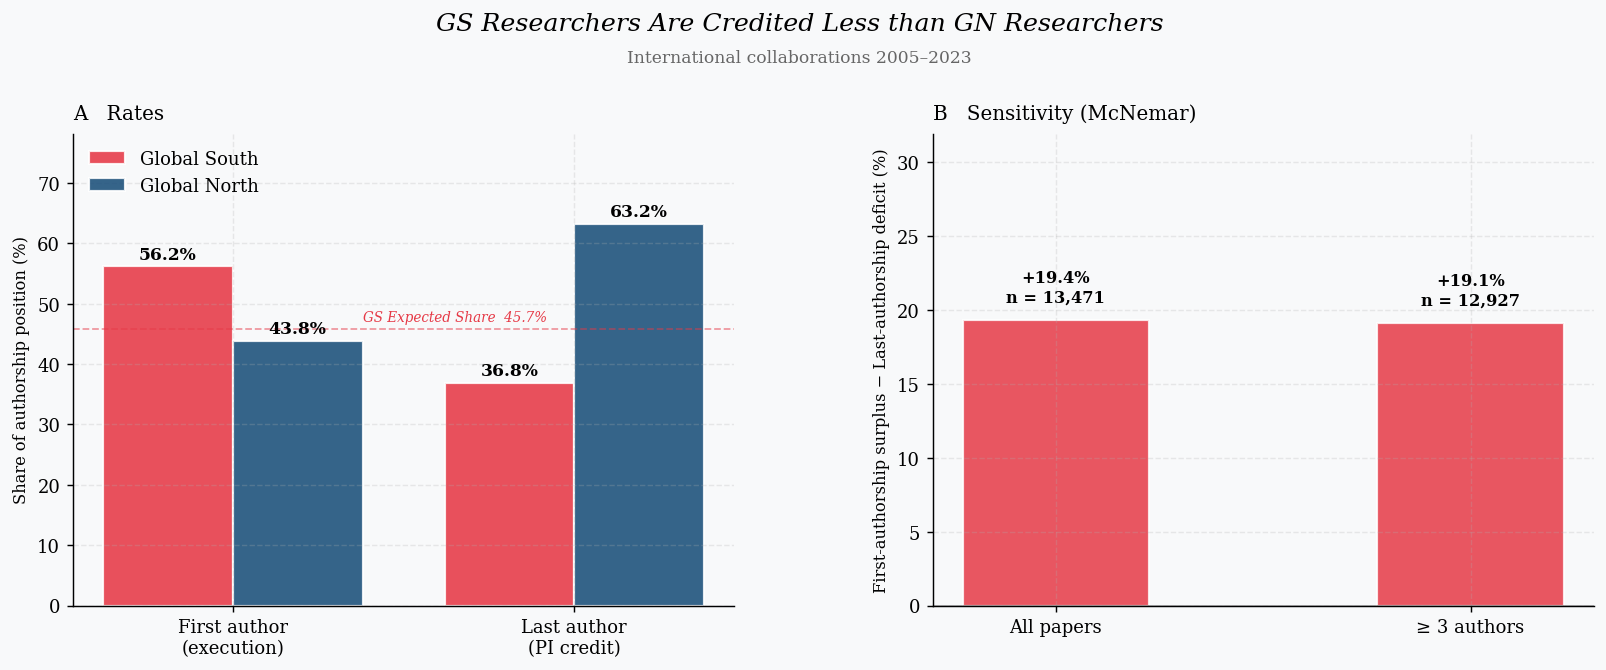

  ✓ saved figures/fig1_rates.png


In [11]:
fig1_rates(df_papers, R["headline"])

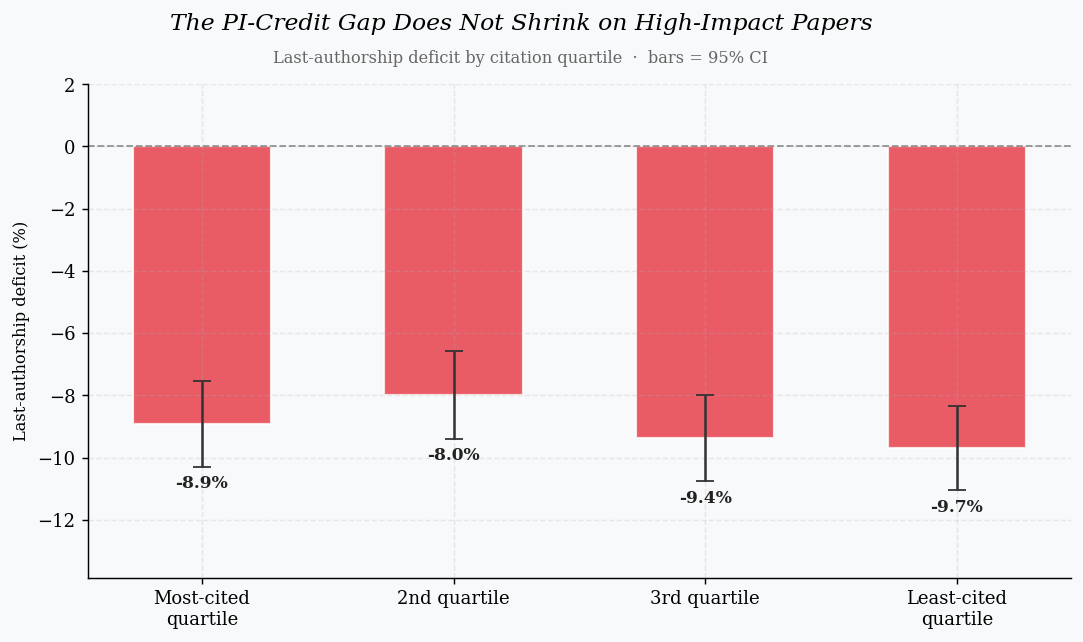

  ✓ saved figures/fig2_citation_quartile.png


In [12]:
fig2_citation_quartile(R["cq_df"])

  116 countries  (73 negative / 43 positive)


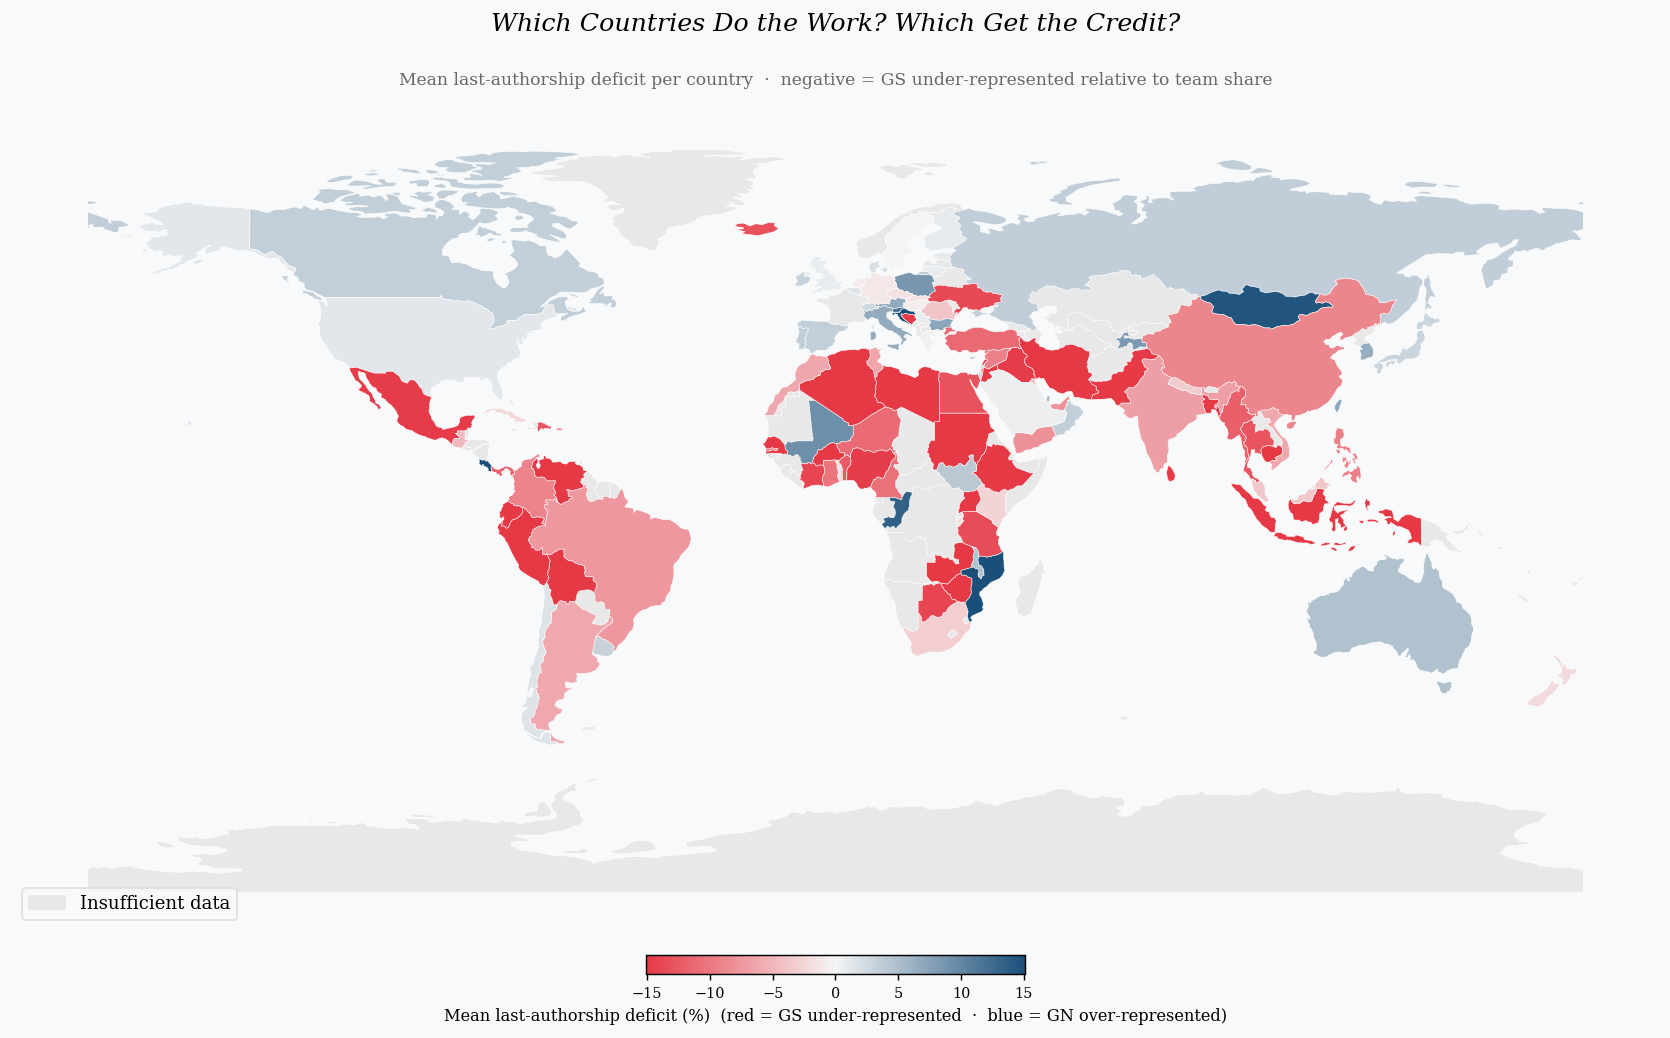

  ✓ saved figures/fig3_choropleth.png


In [13]:
fig3_choropleth(df_authors, df_papers)

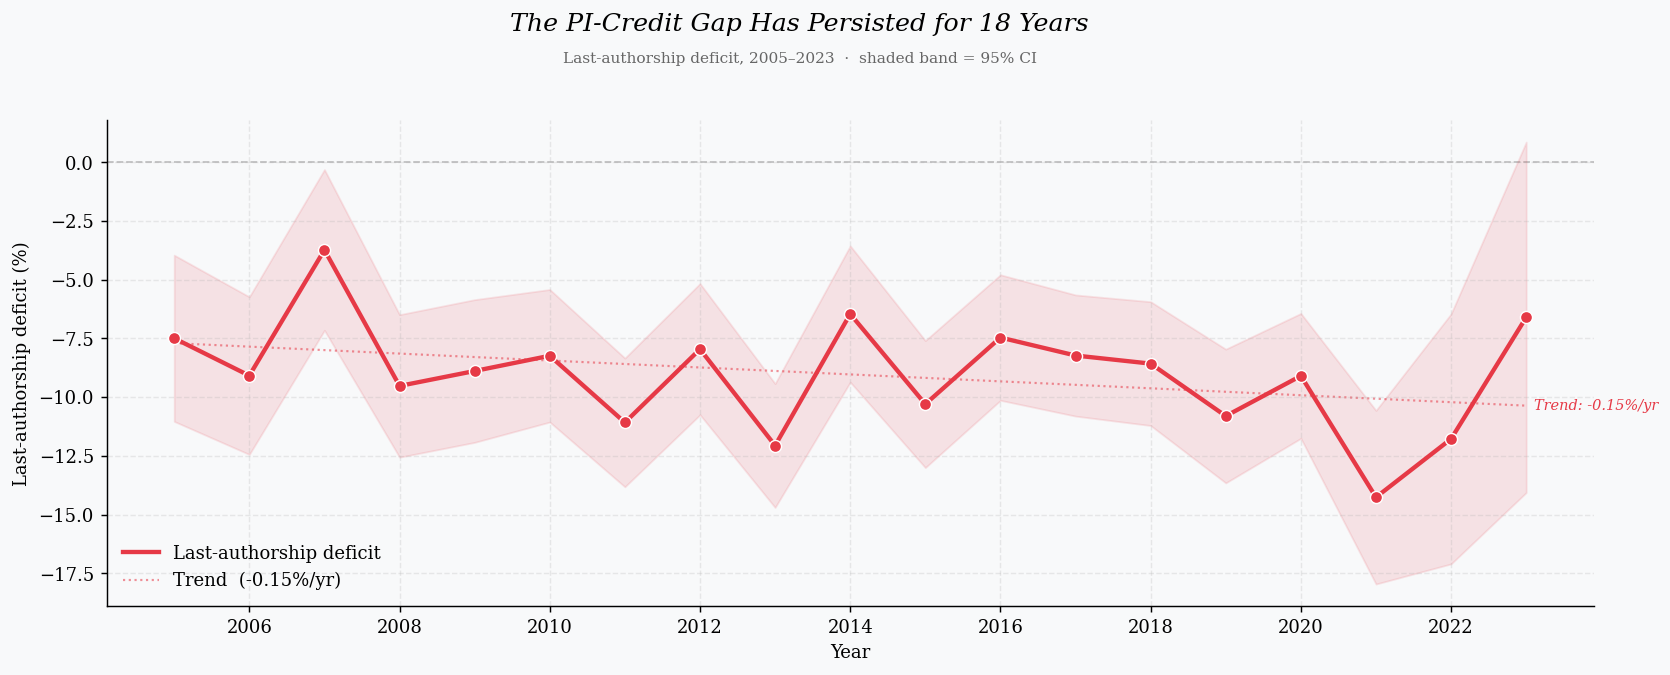

  ✓ saved figures/fig4_trend.png


In [14]:
fig4_trend(df_papers)

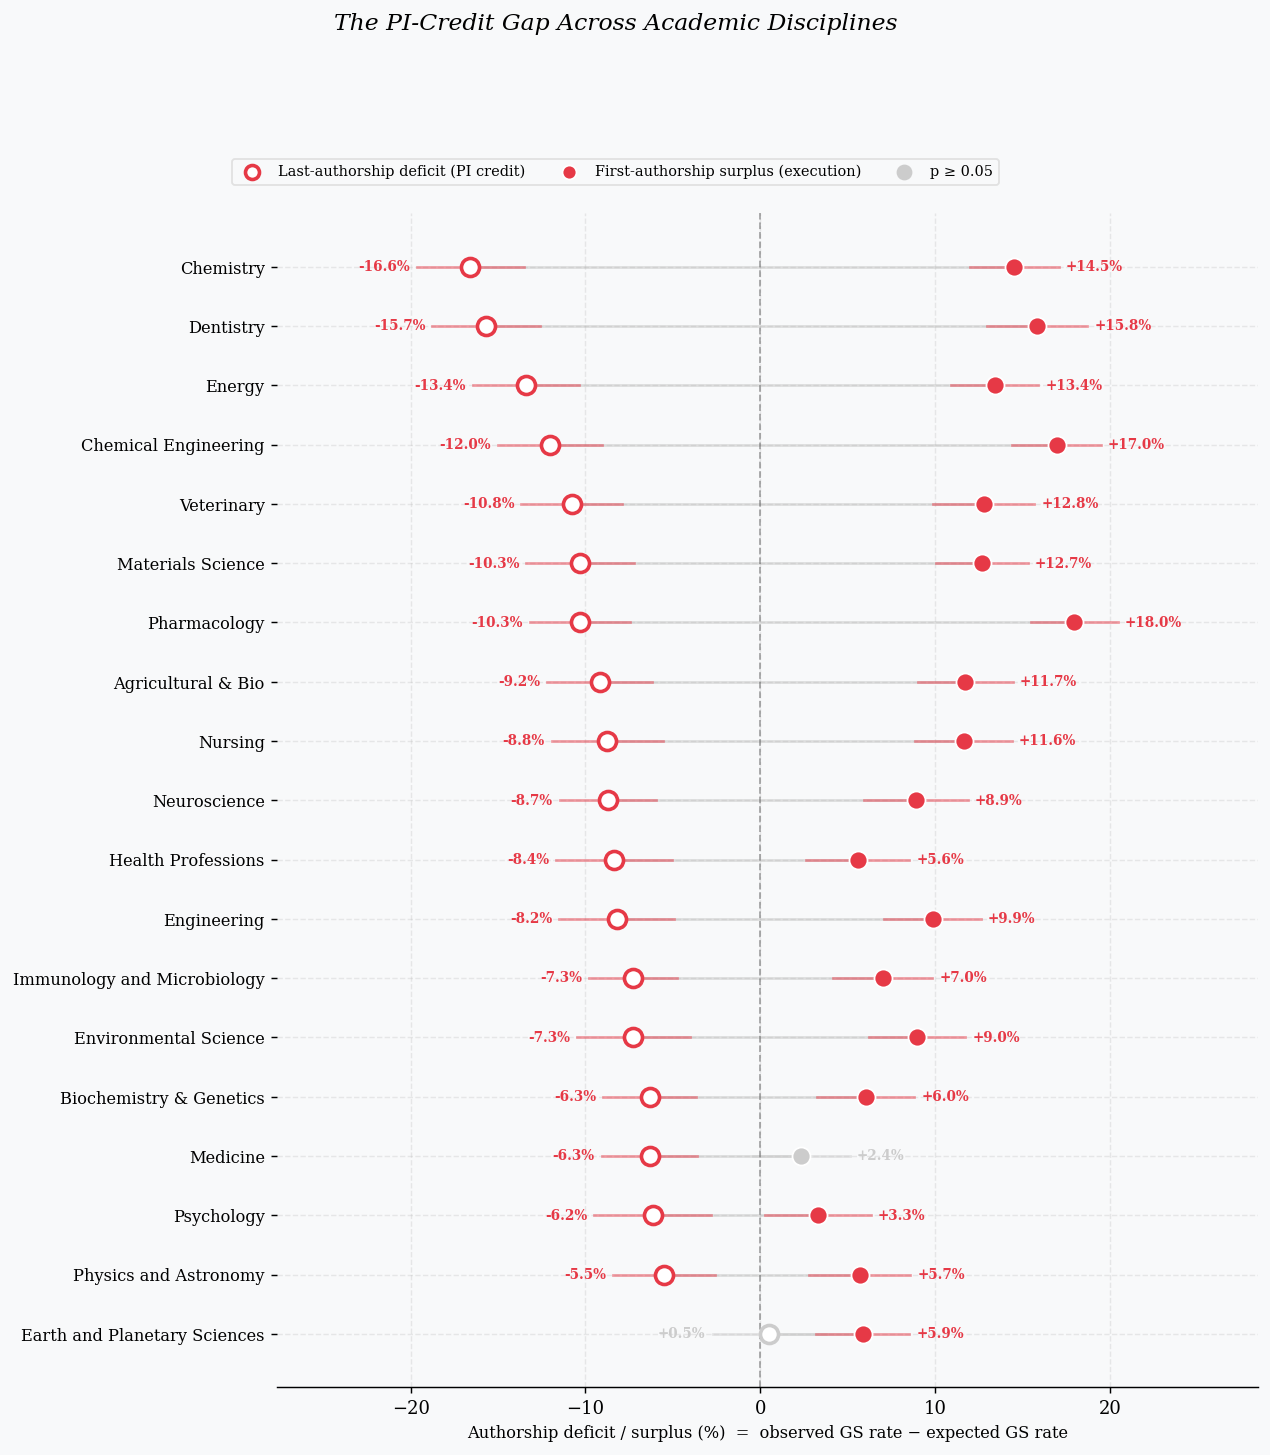

  ✓ saved figures/fig5_field_deficits.png


In [15]:
fig5_field_deficits(df_papers, R["field_df"])